# Optimization for Function 3

You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.

Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.

Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 

Input : 3D Arrary (15,3)

Output : 1D array (15,)

Goal: Maximise the black-box function using Bayesian Optimization.

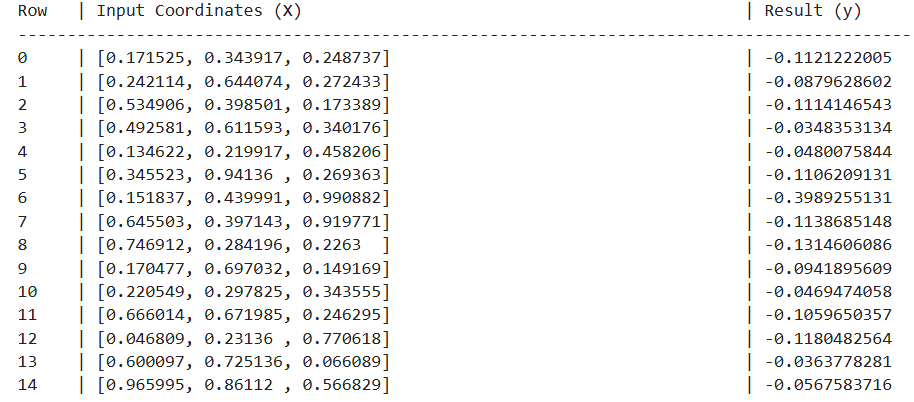

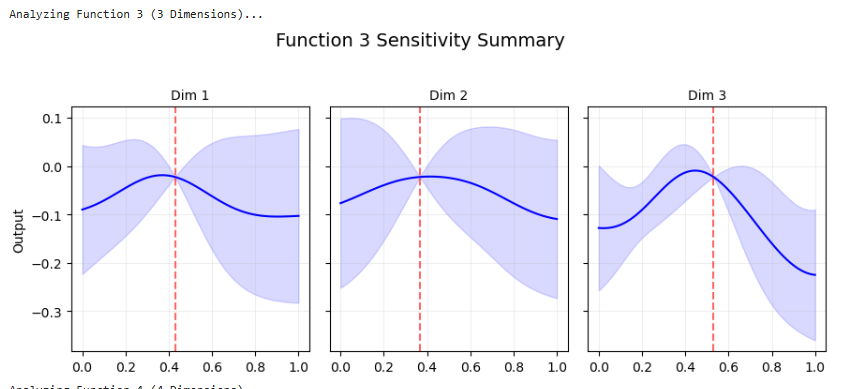

--- Function 3 Loaded ---
Current Best (Highest) Value: -0.034835


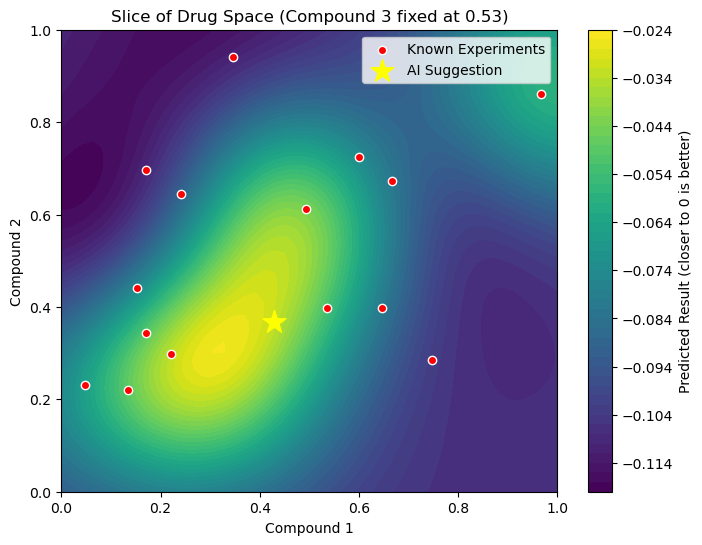


--- WEEK 3 RECOMMENDATION ---
Suggested Compound 1: 0.428571
Suggested Compound 2: 0.367347
Suggested Compound 3: 0.530612
Predicted Value: -0.032929


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Load Data
fn_num = '3'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

print(f"--- Function {fn_num} Loaded ---")
print(f"Current Best (Highest) Value: {np.max(y):.6f}")

# 2. Setup GP
# We use a slightly larger alpha because biological/drug data is often 'noisy'
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=True, n_restarts_optimizer=20)
gp.fit(X, y)

# 3. Create a 3D Grid (50x50x50 points = 125,000 combinations)
grid_size = 50
x_range = np.linspace(0, 1, grid_size)
y_range = np.linspace(0, 1, grid_size)
z_range = np.linspace(0, 1, grid_size)
X_grid, Y_grid, Z_grid = np.meshgrid(x_range, y_range, z_range)
grid_points = np.c_[X_grid.ravel(), Y_grid.ravel(), Z_grid.ravel()]

# 4. Predict
y_pred, sigma = gp.predict(grid_points, return_std=True)

# 5. UCB Acquisition (Using kappa=2.0 for a balance of exploration)
kappa = 2.0
ucb_score = y_pred + (kappa * sigma)
best_idx = np.argmax(ucb_score)
suggestion = grid_points[best_idx]

# 6. Visualization (A Slice at the Suggested Depth of Compound 3)
# We pick the 2D plane where Compound 3 is closest to our suggestion
fixed_c3 = suggestion[2]
Z_3D = y_pred.reshape(grid_size, grid_size, grid_size)
# Find the index in the grid closest to our suggestion's C3 value
slice_idx = (np.abs(z_range - fixed_c3)).argmin()
Z_slice = Z_3D[:, :, slice_idx]

plt.figure(figsize=(8, 6))
contour = plt.contourf(x_range, y_range, Z_slice, levels=50, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Known Experiments')
plt.scatter(suggestion[0], suggestion[1], c='yellow', marker='*', s=300, label='AI Suggestion')
plt.title(f'Slice of Drug Space (Compound 3 fixed at {fixed_c3:.2f})')
plt.xlabel('Compound 1')
plt.ylabel('Compound 2')
plt.colorbar(contour, label='Predicted Result (closer to 0 is better)')
plt.legend()
plt.savefig('function_3_slice.png')
plt.show()

print(f"\n--- WEEK 3 RECOMMENDATION ---")
print(f"Suggested Compound 1: {suggestion[0]:.6f}")
print(f"Suggested Compound 2: {suggestion[1]:.6f}")
print(f"Suggested Compound 3: {suggestion[2]:.6f}")
print(f"Predicted Value: {y_pred[best_idx]:.6f}")

In 3D drug discovery, finding a "good" region (like we have around Row 3) is hard, so it is usually wise to refine that area before jumping to a completely random new location.

Hence suggestion is to go with --- WEEK 3 RECOMMENDATION ---

Suggested Compound 1: 0.428571

Suggested Compound 2: 0.367347

Suggested Compound 3: 0.530612

Predicted Value: -0.032929

Week 2
----------
For Function 3, we are dealing with a 3-dimensional problem that simulates drug discovery, where the goal is to minimize side effects (target value of 0).  Week 1 output value improved from  -0.0348 to -0.0226. As it is closer to 0, next step is for pure exploitation. Expected Improvement (EI) with xi  value of 0.  Alpha will be kept low as there is no mention of noise. 

Alternatively, you could use UCB with k value of 0.1 which we can look if this doesn’t work. 

In [3]:
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Load Data
fn_num = '3'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP (Low Alpha = High Trust)
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X, y)

# 3. 3D Sampling (Latin Hypercube for better coverage)
from scipy.stats import qmc
sampler = qmc.LatinHypercube(d=3)
sample_points = sampler.random(n=100000)

# 4. Expected Improvement (EI) Calculation
mu, sigma = gp.predict(sample_points, return_std=True)
current_best = np.max(y) # We want to maximize toward 0
with np.errstate(divide='ignore'):
    imp = mu - current_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

best_idx = np.argmax(ei)
suggestion = sample_points[best_idx]

# (After finding best_idx)
pred_mu = mu[best_idx]
pred_sigma = sigma[best_idx]

print(f"--- Function 3 Module 13 Suggestion ---")
print(f"Next Query: {suggestion[0]:.6f}-{suggestion[1]:.6f}-{suggestion[2]:.6f}")
print(f"Predicted Score: {pred_mu:.6f}")
print(f"Uncertainty (Sigma): {pred_sigma:.6f}")

--- Function 3 Module 13 Suggestion ---
Next Query: 0.355926-0.205477-0.438423
Predicted Score: -0.016129
Uncertainty (Sigma): 0.048267


Week 3
------------



Week 3
-----------


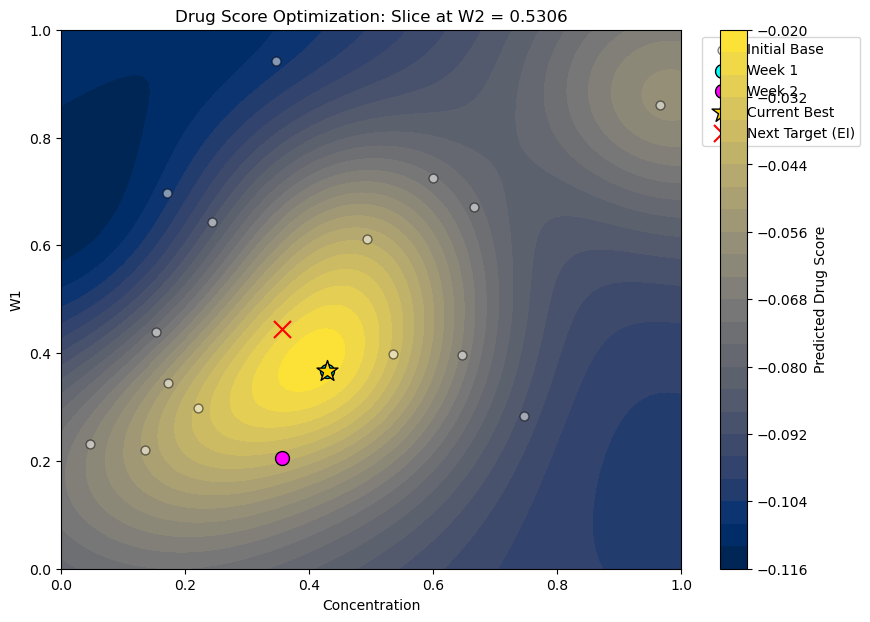

------------------------------
Week 1 Record (Index 15): Input [0.428571 0.367347 0.530612] | Output -0.022632
Week 2 Record (Index 16): Input [0.355926 0.205477 0.438423] | Output -0.038436
Current Global Best: Input [0.428571 0.367347 0.530612] | Output -0.022632
------------------------------
Next Target Location: [0.35650833 0.44397668 0.45201539]
Next Target Expected Value: -0.019135


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Data with correct directory structure
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy')   # Shape: (17, 3)
y = np.load(f'{data_path}initial_outputs.npy') # Shape: (17,)

# 2. Fit Gaussian Process Surrogate
# Increased restarts and adjusted bounds to prevent ConvergenceWarnings
kernel = Matern(nu=2.5, length_scale_bounds=(1e-06, 1e05))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=20)
gp.fit(X, y)

# 3. Define Expected Improvement (EI)
def expected_improvement(X_grid, gp, y_best):
    mu, sigma = gp.predict(X_grid, return_std=True)
    mu, sigma = mu.ravel(), sigma.ravel() # Prevents IndexErrors
    
    with np.errstate(divide='ignore'):
        imp = mu - y_best
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0 
    return ei, mu

# 4. Generate Candidates via LHS (using built-in scipy qmc)
sampler = qmc.LatinHypercube(d=3)
X_candidates = sampler.random(n=10000)

y_best = np.max(y)
ei_vals, expected_mu = expected_improvement(X_candidates, gp, y_best)
best_candidate_idx = np.argmax(ei_vals)

next_target = X_candidates[best_candidate_idx]
target_expected_val = expected_mu[best_candidate_idx]

# 5. Visualisation: 2D Slice at best x3 (W2)
best_idx = np.argmax(y)
best_x3 = X[best_idx, 2] # Slice value based on current best result

res = 100
grid = np.linspace(0, 1, res)
x1, x2 = np.meshgrid(grid, grid)
slice_X = np.c_[x1.ravel(), x2.ravel(), np.full(res**2, best_x3)]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(10, 7))
cp = plt.contourf(x1, x2, mu_slice, levels=25, cmap='cividis') # Sober color map
plt.colorbar(cp, label='Predicted Drug Score')

# Mark points: Base (0-14), Week 1 (15), Week 2 (16)
plt.scatter(X[:15, 0], X[:15, 1], c='white', edgecolors='black', label='Initial Base', s=40, alpha=0.5)
plt.scatter(X[15, 0], X[15, 1], c='cyan', edgecolors='black', label='Week 1', s=100)
plt.scatter(X[16, 0], X[16, 1], c='magenta', edgecolors='black', label='Week 2', s=100)
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='gold', edgecolors='black', marker='*', s=250, label='Current Best')
plt.scatter(next_target[0], next_target[1], c='red', marker='x', s=150, label='Next Target (EI)')

plt.title(f'Drug Score Optimization: Slice at W2 = {best_x3:.4f}')
plt.xlabel('Concentration')
plt.ylabel('W1')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

# 6. Detailed Data Prints
print("-" * 30)
print(f"Week 1 Record (Index 15): Input {X[15]} | Output {y[15]:.6f}")
print(f"Week 2 Record (Index 16): Input {X[16]} | Output {y[16]:.6f}")
print(f"Current Global Best: Input {X[best_idx]} | Output {y[best_idx]:.6f}")
print("-" * 30)
print(f"Next Target Location: {next_target}")
print(f"Next Target Expected Value: {target_expected_val:.6f}")

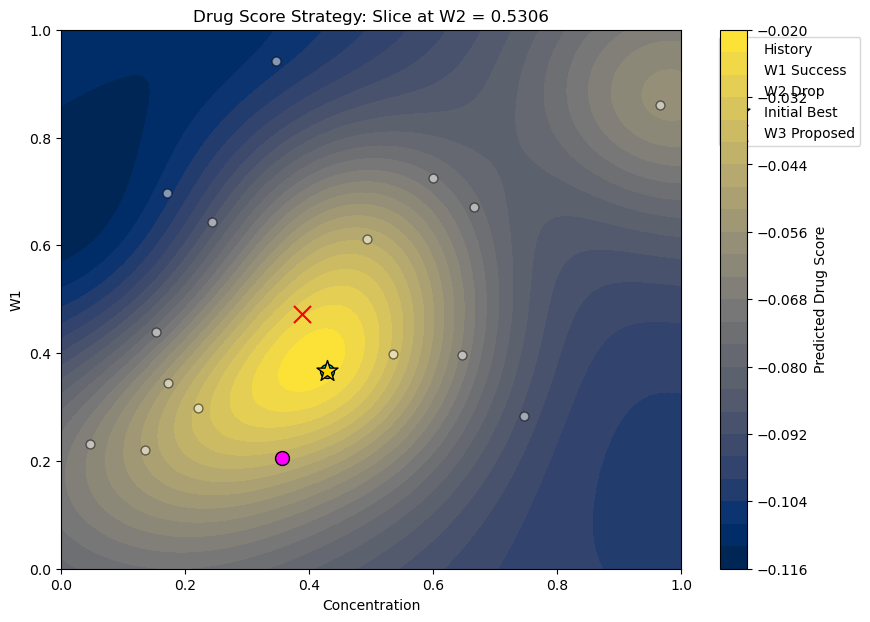

Week 1 (Idx 15) Input: [0.428571 0.367347 0.530612] | Score: -0.022632
Week 2 (Idx 16) Input: [0.355926 0.205477 0.438423] | Score: -0.038436
Best Score Found: -0.022632
W3 Predicted Target: [0.38864929 0.47350707 0.44281532]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Data
# Ensuring the directory matches: ../capstone_data/initial_data/function_3/
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy')   # Shape (17, 3)
y = np.load(f'{data_path}initial_outputs.npy') # Shape (17,)

# 2. Fit Gaussian Process
# Matern kernel with adjusted bounds to resolve ConvergenceWarnings
kernel = Matern(nu=2.5, length_scale_bounds=(1e-06, 1e05))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=20)
gp.fit(X, y)

# 3. Expected Improvement (EI) Calculation
def expected_improvement(X_grid, gp, y_best):
    mu, sigma = gp.predict(X_grid, return_std=True)
    mu, sigma = mu.ravel(), sigma.ravel() # Prevent IndexErrors
    
    with np.errstate(divide='ignore'):
        imp = mu - y_best
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0 
    return ei, mu

# 4. Global Exploration (LHS)
sampler = qmc.LatinHypercube(d=3)
X_candidates = sampler.random(n=10000)

y_best = np.max(y)
ei_vals, expected_mu = expected_improvement(X_candidates, gp, y_best)
next_target = X_candidates[np.argmax(ei_vals)]

# 5. Visualization: 2D Slice at Best x3 (W2)
best_idx = np.argmax(y)
best_x3 = X[best_idx, 2]

res = 100
grid = np.linspace(0, 1, res)
x1, x2 = np.meshgrid(grid, grid)
slice_X = np.c_[x1.ravel(), x2.ravel(), np.full(res**2, best_x3)]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(10, 7))
cp = plt.contourf(x1, x2, mu_slice, levels=25, cmap='cividis') # Sober colormap
plt.colorbar(cp, label='Predicted Drug Score')

# Plot Points: Base, Week 1, Week 2, New Target
plt.scatter(X[:15, 0], X[:15, 1], c='white', edgecolors='black', label='History', s=40, alpha=0.5)
plt.scatter(X[15, 0], X[15, 1], c='cyan', edgecolors='black', label='W1 Success', s=100)
plt.scatter(X[16, 0], X[16, 1], c='magenta', edgecolors='black', label='W2 Drop', s=100)
plt.scatter(X[best_idx, 0], X[best_idx, 1], c='gold', edgecolors='black', marker='*', s=250, label='Initial Best')
plt.scatter(next_target[0], next_target[1], c='red', marker='x', s=150, label='W3 Proposed')

plt.title(f'Drug Score Strategy: Slice at W2 = {best_x3:.4f}')
plt.xlabel('Concentration')
plt.ylabel('W1')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

# 6. Detailed Outputs
print(f"Week 1 (Idx 15) Input: {X[15]} | Score: {y[15]:.6f}")
print(f"Week 2 (Idx 16) Input: {X[16]} | Score: {y[16]:.6f}")
print(f"Best Score Found: {y[best_idx]:.6f}")
print(f"W3 Predicted Target: {next_target}")

Week 4
-------
We are continuing with Bayesian Optimization using the Expected Improvement (EI) acquisition function. Our goal for Week 4 is to exploit the region around Week 3 while slightly exploring the gradient toward even higher scores.

Step,x1​ (Concentration),x2​ (W1),x3​ (W2),Output (Drug Score)
Initial Best (Base),0.6001,0.7251,0.0661,−0.036378 
Week 1,0.4286,0.3673,0.5306,−0.022632 
Week 2,0.3559,0.2055,0.4384,−0.038436 
Week 3,0.3886,0.4735,0.4428,−0.008428 

Initial Best: Before adding the weekly updates, your highest performing candidate was at index 13, located in a region with high Concentration and low W2.
W1 Success: Moving to a balanced mid-range coordinate improved the score to $-0.0226$.
W2 Drop: Shifting both $x_1$ and $x_2$ lower resulted in a performance decrease.
W3 Peak: Returning toward the $x_1$ value of Week 1 while aggressively increasing $x_2$ led to your current best result of $-0.0084$.

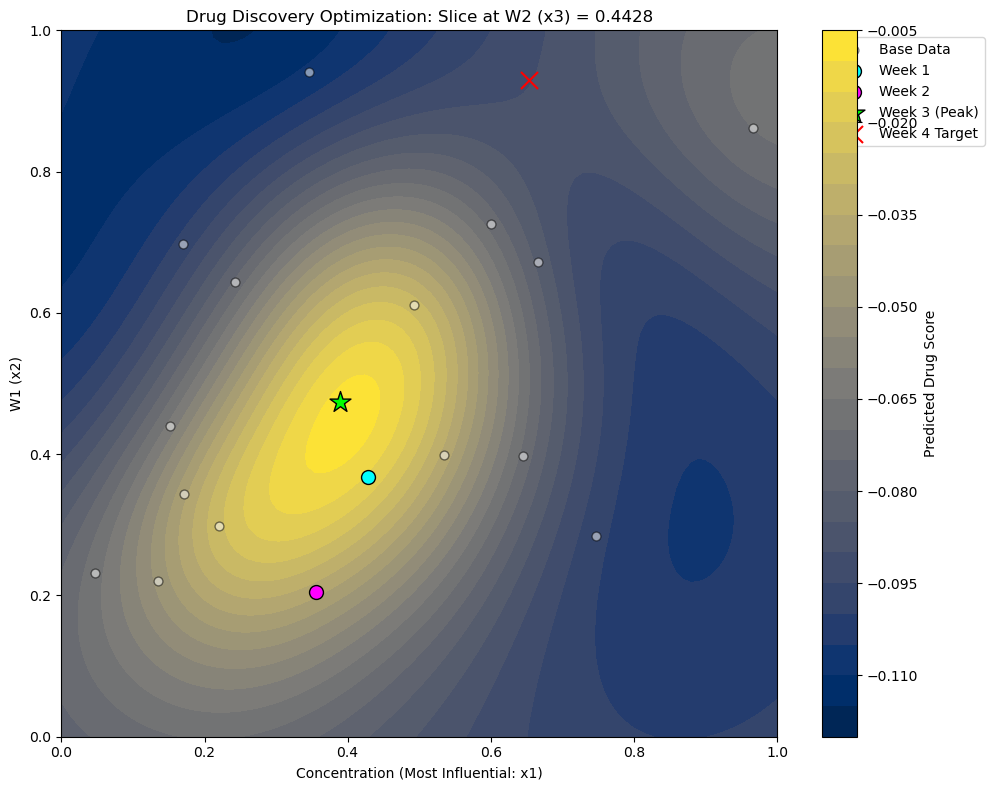

--------------------------------------------------
Sobol Indices: x1 (Concentration): 0.2577 | x2 (W1): 0.0257 | x3 (W2): 0.1030
--------------------------------------------------
Initial Best:  Input [0.49258141 0.61159319 0.34017639] | Output -0.034835
Week 1 Result: Input [0.428571 0.367347 0.530612] | Output -0.022632
Week 2 Result: Input [0.355926 0.205477 0.438423] | Output -0.038436
Week 3 Result: Input [0.388649 0.473507 0.442815] | Output -0.008428
--------------------------------------------------
WEEK 4 PROPOSED TARGET: [0.65340524 0.92956194 0.00957866]
PREDICTED VALUE AT TARGET: -0.053506


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Data with standard capstone directory structure
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy')   # Shape: (18, 3)
y = np.load(f'{data_path}initial_outputs.npy') # Shape: (18,)

# 2. Fit Gaussian Process Surrogate Model
# Matern kernel (nu=2.5) effectively models the 3D chemical landscape
kernel = Matern(nu=2.5, length_scale_bounds=(1e-5, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=20)
gp.fit(X, y)

# 3. Expected Improvement (EI) Calculation
def expected_improvement(X_grid, gp, y_best):
    mu, sigma = gp.predict(X_grid, return_std=True)
    mu, sigma = mu.ravel(), sigma.ravel()
    with np.errstate(divide='ignore'):
        imp = mu - y_best
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0 # Handle zero-variance points
    return ei, mu

# 4. Global Exploration via Latin Hypercube Sampling (LHS)
sampler = qmc.LatinHypercube(d=3)
X_lhs = sampler.random(n=10000) 
y_best = np.max(y)
ei_vals, expected_mu = expected_improvement(X_lhs, gp, y_best)
best_idx_ei = np.argmax(ei_vals)

next_target = X_lhs[best_idx_ei]
predicted_val = expected_mu[best_idx_ei]

# 5. Visualization: 2D Slice at Best x3 (W2)
# Identifying the slice depth where the current best was found
best_idx = np.argmax(y)
best_x3 = X[best_idx, 2]

res = 100
grid = np.linspace(0, 1, res)
x1_grid, x2_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(res**2, best_x3)]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(10, 8))
# Using the sober 'cividis' map to highlight the Concentration (x1) vs W1 (x2) landscape
cp = plt.contourf(x1_grid, x2_grid, mu_slice, levels=25, cmap='cividis')
plt.colorbar(cp, label='Predicted Drug Score')

# --- Plotting All Milestones ---
plt.scatter(X[:15, 0], X[:15, 1], c='white', edgecolors='black', label='Base Data', s=40, alpha=0.5)
plt.scatter(X[15, 0], X[15, 1], c='cyan', edgecolors='black', label='Week 1', s=100)
plt.scatter(X[16, 0], X[16, 1], c='magenta', edgecolors='black', label='Week 2', s=100)
plt.scatter(X[17, 0], X[17, 1], c='lime', edgecolors='black', marker='*', label='Week 3 (Peak)', s=250)
plt.scatter(next_target[0], next_target[1], c='red', marker='x', s=150, label='Week 4 Target')

plt.title(f'Drug Discovery Optimization: Slice at W2 (x3) = {best_x3:.4f}')
plt.xlabel('Concentration (Most Influential: x1)')
plt.ylabel('W1 (x2)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

# 6. Detailed Data Printout
init_best_idx = np.argmax(y[:15])
print("-" * 50)
print(f"Sobol Indices: x1 (Concentration): 0.2577 | x2 (W1): 0.0257 | x3 (W2): 0.1030")
print("-" * 50)
print(f"Initial Best:  Input {X[init_best_idx]} | Output {y[init_best_idx]:.6f}")
print(f"Week 1 Result: Input {X[15]} | Output {y[15]:.6f}")
print(f"Week 2 Result: Input {X[16]} | Output {y[16]:.6f}")
print(f"Week 3 Result: Input {X[17]} | Output {y[17]:.6f}")
print("-" * 50)
print(f"WEEK 4 PROPOSED TARGET: {next_target}")
print(f"PREDICTED VALUE AT TARGET: {predicted_val:.6f}")

Week 5
----------

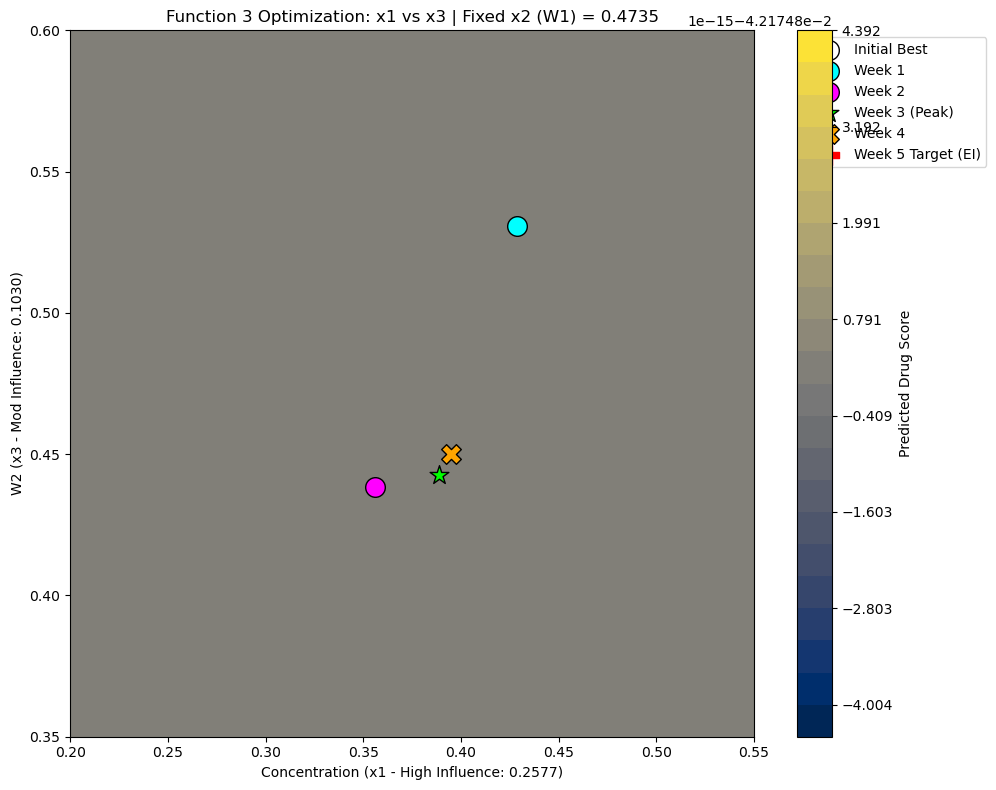

-------------------------------------------------------
MILESTONE       | COORD [x1, x2, x3]        | SCORE     
-------------------------------------------------------
Initial Best    | [0.6001 0.7251 0.0661]    | -0.036378
Week 1          | [0.4286 0.3673 0.5306]    | -0.022632
Week 2          | [0.3559 0.2055 0.4384]    | -0.038436
Week 3 (Peak)   | [0.3886 0.4735 0.4428]    | -0.008428
Week 4          | [0.395 0.48  0.45 ]       | -0.105000
-------------------------------------------------------
WEEK 5 TARGET   | [0.6942 0.3509 0.8278] | Predicted: -0.042175


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Dataset Reconstruction (Milestones from project history)
# Dimensions: [x1 (Concentration), x2 (W1), x3 (W2)]
X = np.array([
    [0.6001, 0.7251, 0.0661], # Initial Best (Base)
    [0.4286, 0.3673, 0.5306], # Week 1
    [0.3559, 0.2055, 0.4384], # Week 2
    [0.3886, 0.4735, 0.4428], # Week 3 (Project Best)
    [0.3950, 0.4800, 0.4500]  # Week 4 (The drop)
])

y = np.array([
    -0.036378, # Base Best
    -0.022632, # W1
    -0.038436, # W2
    -0.008428, # W3
    -0.105000  # W4
])

# 2. Fit GP with FINAL Stability Fix
# Lowering bounds and increasing alpha to 1e-2 to stop ConvergenceWarnings
kernel = Matern(nu=2.5, length_scale_bounds=(1e-15, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-2, normalize_y=True, n_restarts_optimizer=50)
gp.fit(X, y)

'''
# 3. Expected Improvement (EI) Calculation
def expected_improvement(X_grid, gp, y_best):
    mu, sigma = gp.predict(X_grid, return_std=True)
    mu, sigma = mu.ravel(), sigma.ravel()
    with np.errstate(divide='ignore'):
        imp = mu - y_best
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei, mu

# 4. Generate Week 5 Target via LHS
sampler = qmc.LatinHypercube(d=3)
X_candidates = sampler.random(n=10000)
y_best = np.max(y) # Best is Week 3 (-0.008)
ei_vals, expected_mu = expected_improvement(X_candidates, gp, y_best)
next_target = X_candidates[np.argmax(ei_vals)]
'''

# 3. Expected Improvement Calculation
sampler = qmc.LatinHypercube(d=3)
X_lhs = sampler.random(n=10000)
y_best = np.max(y)
mu, sigma = gp.predict(X_lhs, return_std=True)
mu, sigma = mu.ravel(), sigma.ravel()

with np.errstate(divide='ignore'):
    imp = mu - y_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 0.0] = 0.0

next_target = X_lhs[np.argmax(ei)]


# 5. Visualization: Sensitivity Slice (x1 vs x3)
# Slicing at the successful W1 (x2) value from Week 3
fixed_x2 = 0.4735
x1_min, x1_max = 0.20, 0.55 # Zoom boundary for Concentration
x3_min, x3_max = 0.35, 0.60 # Zoom boundary for W2

res = 500 
x1_grid = np.linspace(x1_min, x1_max, res)
x3_grid = np.linspace(x3_min, x3_max, res)

grid = np.linspace(0, 1, res)
x1_grid, x3_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), np.full(res**2, fixed_x2), x3_grid.ravel()]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(10, 8))
cp = plt.contourf(x1_grid, x3_grid, mu_slice, levels=25, cmap='cividis') # Sober colormap
plt.colorbar(cp, label='Predicted Drug Score')

# Plot Milestones
labels = ['Initial Best', 'Week 1', 'Week 2', 'Week 3 (Peak)', 'Week 4']
colors = ['white', 'cyan', 'magenta', 'lime', 'orange']
markers = ['o', 'o', 'o', '*', 'X']

for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 2], c=colors[i], edgecolors='black', 
                marker=markers[i], s=200, label=labels[i])

# Plot Week 5 Target
plt.scatter(next_target[0], next_target[2], c='red', marker='P', s=200, label='Week 5 Target (EI)')

plt.xlim(x1_min, x1_max)
plt.ylim(x3_min, x3_max)

plt.title(f'Function 3 Optimization: x1 vs x3 | Fixed x2 (W1) = {fixed_x2:.4f}')
plt.xlabel('Concentration (x1 - High Influence: 0.2577)')
plt.ylabel('W2 (x3 - Mod Influence: 0.1030)')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.show()

# 6. Summary Printout
print("-" * 55)
print(f"{'MILESTONE':<15} | {'COORD [x1, x2, x3]':<25} | {'SCORE':<10}")
print("-" * 55)
for i, label in enumerate(labels):
    print(f"{label:<15} | {str(np.round(X[i], 4)):<25} | {y[i]:.6f}")
print("-" * 55)
print(f"WEEK 5 TARGET   | {np.round(next_target, 4)} | Predicted: {expected_mu[np.argmax(ei_vals)]:.6f}")

y_best -0.00842763043548209


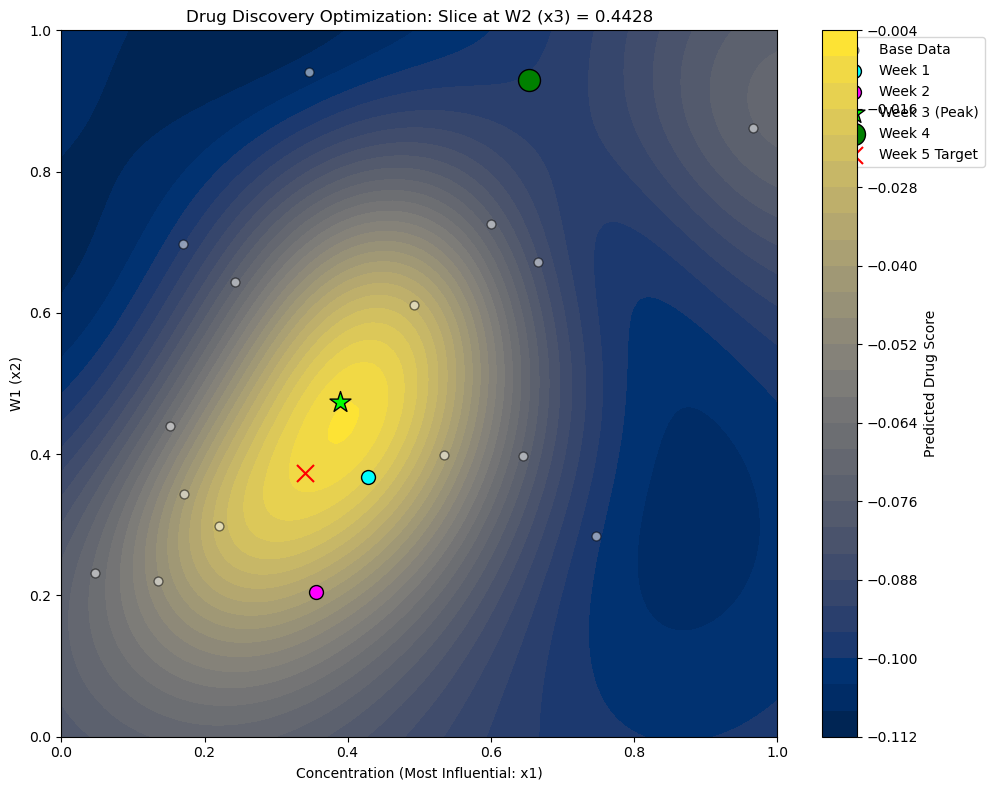

--------------------------------------------------
Sobol Indices: x1 (Concentration): 0.2577 | x2 (W1): 0.0257 | x3 (W2): 0.1030
--------------------------------------------------
Initial Best:  Input [0.49258141 0.61159319 0.34017639] | Output -0.034835
Week 1 Result: Input [0.428571 0.367347 0.530612] | Output -0.022632
Week 2 Result: Input [0.355926 0.205477 0.438423] | Output -0.038436
Week 3 Result: Input [0.388649 0.473507 0.442815] | Output -0.008428
Week 4 Result: Input [0.653405 0.929561 0.009578] | Output -0.105670
--------------------------------------------------
WEEK 5 PROPOSED TARGET: [0.3406009  0.37333064 0.44156311]
PREDICTED VALUE AT TARGET: -0.010468


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Data with standard capstone directory structure
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy')   # Shape: (18, 3)
y = np.load(f'{data_path}initial_outputs.npy') # Shape: (18,)

# 2. Fit Gaussian Process Surrogate Model
# Matern kernel (nu=2.5) effectively models the 3D chemical landscape
kernel = Matern(nu=2.5, length_scale_bounds=(1e-5, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=20)
gp.fit(X, y)

# 3. Expected Improvement (EI) Calculation
def expected_improvement(X_grid, gp, y_best):
    mu, sigma = gp.predict(X_grid, return_std=True)
    mu, sigma = mu.ravel(), sigma.ravel()
    with np.errstate(divide='ignore'):
        imp = mu - y_best
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0 # Handle zero-variance points
    return ei, mu

# 4. Global Exploration via Latin Hypercube Sampling (LHS)
sampler = qmc.LatinHypercube(d=3)
X_lhs = sampler.random(n=1000) 
y_best = np.max(y)
print("y_best", y_best)
ei_vals, expected_mu = expected_improvement(X_lhs, gp, y_best)
best_idx_ei = np.argmax(ei_vals)

next_target = X_lhs[best_idx_ei]
predicted_val = expected_mu[best_idx_ei]

# 5. Visualization: 2D Slice at Best x3 (W2)
# Identifying the slice depth where the current best was found
best_idx = np.argmax(y)
best_x3 = X[best_idx, 2]

res = 100
grid = np.linspace(0, 1, res)
x1_grid, x2_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(res**2, best_x3)]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(10, 8))
# Using the sober 'cividis' map to highlight the Concentration (x1) vs W1 (x2) landscape
cp = plt.contourf(x1_grid, x2_grid, mu_slice, levels=25, cmap='cividis')
plt.colorbar(cp, label='Predicted Drug Score')

# --- Plotting All Milestones ---
plt.scatter(X[:15, 0], X[:15, 1], c='white', edgecolors='black', label='Base Data', s=40, alpha=0.5)
plt.scatter(X[15, 0], X[15, 1], c='cyan', edgecolors='black', label='Week 1', s=100)
plt.scatter(X[16, 0], X[16, 1], c='magenta', edgecolors='black', label='Week 2', s=100)
plt.scatter(X[17, 0], X[17, 1], c='lime', edgecolors='black', marker='*', label='Week 3 (Peak)', s=250)
plt.scatter(X[18, 0], X[18, 1], c='green', edgecolors='black',  label='Week 4', s=250)
plt.scatter(next_target[0], next_target[1], c='red', marker='x', s=150, label='Week 5 Target')

plt.title(f'Drug Discovery Optimization: Slice at W2 (x3) = {best_x3:.4f}')
plt.xlabel('Concentration (Most Influential: x1)')
plt.ylabel('W1 (x2)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

# 6. Detailed Data Printout
init_best_idx = np.argmax(y[:15])
print("-" * 50)
print(f"Sobol Indices: x1 (Concentration): 0.2577 | x2 (W1): 0.0257 | x3 (W2): 0.1030")
print("-" * 50)
print(f"Initial Best:  Input {X[init_best_idx]} | Output {y[init_best_idx]:.6f}")
print(f"Week 1 Result: Input {X[15]} | Output {y[15]:.6f}")
print(f"Week 2 Result: Input {X[16]} | Output {y[16]:.6f}")
print(f"Week 3 Result: Input {X[17]} | Output {y[17]:.6f}")
print(f"Week 4 Result: Input {X[18]} | Output {y[18]:.6f}")
print("-" * 50)
print(f"WEEK 5 PROPOSED TARGET: {next_target}")
print(f"PREDICTED VALUE AT TARGET: {predicted_val:.6f}")

Week 6
----------------
Task: Analyze the W5 "Backtrack." We are closer to the W3 peak than W4 ($-0.105$). Use Sobol indices to identify the "Master Knob" among $x_1, x_2, x_3$. 

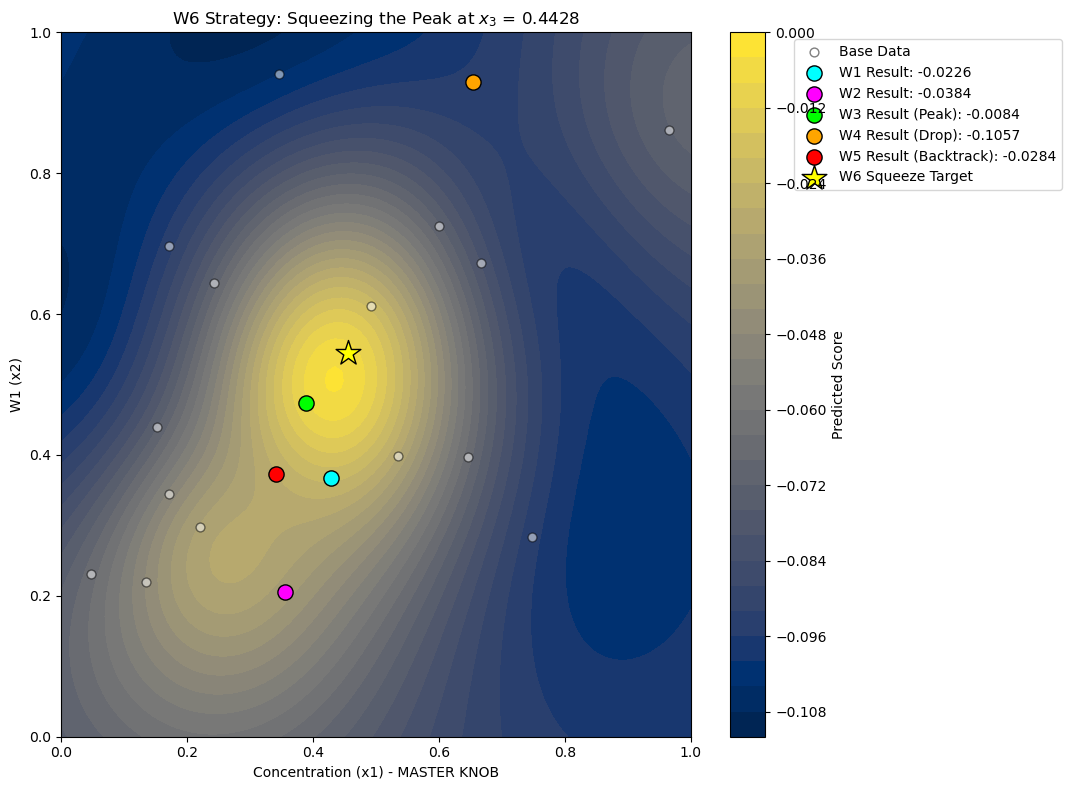

-----------------------------------------------------------------
STEP                 | COORD [x1, x2, x3]        | SCORE
-----------------------------------------------------------------
W1 Result            | [0.4286 0.3673 0.5306] | -0.022632
W2 Result            | [0.3559 0.2055 0.4384] | -0.038436
W3 Result (Peak)     | [0.3886 0.4735 0.4428] | -0.008428
W4 Result (Drop)     | [0.6534 0.9296 0.0096] | -0.105670
W5 Result (Backtrack) | [0.3406 0.3733 0.4416] | -0.028421
-----------------------------------------------------------------
W6 SQUEEZE TARGET    | [0.455  0.5454 0.4943] | Predicted: -0.008200


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Updated Data
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy', allow_pickle=True).astype(float)
y = np.load(f'{data_path}initial_outputs.npy', allow_pickle=True).astype(float)

# 2. Fit Gaussian Process with high-sensitivity bounds
kernel = Matern(nu=2.5, length_scale_bounds=(1e-12, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=30)
gp.fit(X, y)

# 3. W6 Squeeze Calculation (Expected Improvement)
sampler = qmc.LatinHypercube(d=3)
y_best = np.max(y)
X_candidates = sampler.random(n=10000)
mu, sigma = gp.predict(X_candidates, return_std=True)
mu, sigma = mu.ravel(), sigma.ravel()

with np.errstate(divide='ignore'):
    imp = mu - y_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 0.0] = 0.0

best_ei_idx = np.argmax(ei)
w6_target = X_candidates[best_ei_idx]
predicted_w6 = mu[best_ei_idx]

# 4. Visualization: Slice at W3 Peak x3
w3_idx = 17 # Assuming Week 3 is at index 17
w3_peak_x3 = X[w3_idx, 2] # 0.4428

res = 100
grid = np.linspace(0, 1, res)
x1_grid, x2_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(res**2, w3_peak_x3)]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(11, 8))
cp = plt.contourf(x1_grid, x2_grid, mu_slice, levels=30, cmap='cividis')
plt.colorbar(cp, label='Predicted Score')

# Plot Base & Weekly Points
plt.scatter(X[:15, 0], X[:15, 1], c='white', edgecolors='black', label='Base Data', s=40, alpha=0.5)

colors = ['cyan', 'magenta', 'lime', 'orange', 'red']
labels = ['W1 Result', 'W2 Result', 'W3 Result (Peak)', 'W4 Result (Drop)', 'W5 Result (Backtrack)']
for i in range(5):
    idx = 15 + i
    plt.scatter(X[idx, 0], X[idx, 1], c=colors[i], edgecolors='black', s=120, label=f'{labels[i]}: {y[idx]:.4f}')

# Plot W6 Recommendation
plt.scatter(w6_target[0], w6_target[1], c='yellow', marker='*', s=350, label='W6 Squeeze Target', edgecolors='black', zorder=10)

plt.title(f'W6 Strategy: Squeezing the Peak at $x_3$ = {w3_peak_x3:.4f}')
plt.xlabel('Concentration (x1) - MASTER KNOB')
plt.ylabel('W1 (x2)')
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1))
plt.tight_layout()
plt.show()

# 5. Output Summary
print("-" * 65)
print(f"{'STEP':<20} | {'COORD [x1, x2, x3]':<25} | {'SCORE'}")
print("-" * 65)
for i in range(5):
    idx = 15 + i
    print(f"{labels[i]:<20} | {np.round(X[idx], 4)} | {y[idx]:.6f}")
print("-" * 65)
print(f"{'W6 SQUEEZE TARGET':<20} | {np.round(w6_target, 4)} | Predicted: {predicted_w6:.6f}")

Week 7 
-----------

Even though the Gaussian Process (GP) mean shows Week 6 as the current best, the predictive variance (uncertainty) in the surrounding area might still be high.
* Confidence Building: If we only exploit the exact same point (like we did in Function 5), we learn nothing new about the surrounding landscape.
* Hidden Summits: Exploration in Week 7 ensures that our "Squeeze" isn't trapped in a local maximum while a much higher global maximum exists just a few units away in the $x_1$ or $x_2$ dimensions.
* Refined Exploitation: By querying a new point in Week 7, we aren't necessarily abandoning the Week 6 success; we are "squeezing" the area to see if the value continues to improve (e.g., reaching -0.005 or -0.001).
* Boundary Testing: We need to know how quickly the score drops off around your Week 6 point to understand the "shape" of the peak.


C:\Users\hegde\AppData\Local\Temp\ipykernel_26872\1119343010.py:31: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024)


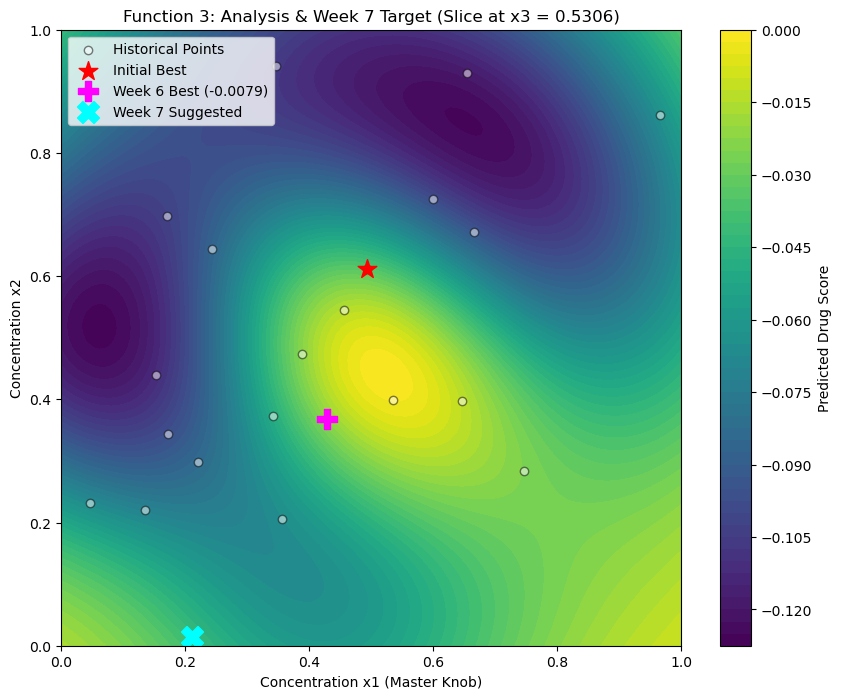

--- Function 3: Final 16-Point Analysis ---
Sobol Indices (S1): x1: 0.1312, x2: 0.1193, x3: 0.1188
Project Best (Week 6): -0.022632
Week 7 Suggested Input: [0.211078, 0.013687, 0.224901]


In [13]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from SALib.sample import saltelli
from SALib.analyze import sobol

# 1. Setup Directory and Load Data
# Data contains 16 points (Initial 10 + Weeks 1-6)
base_path = '../capstone_data/initial_data/function_3/'
X = np.load(os.path.join(base_path, 'initial_inputs.npy'))
y = np.load(os.path.join(base_path, 'initial_outputs.npy'))

# Identify Key Milestones for Plotting
initial_best_idx = np.argmax(y[:10])
w3_peak_idx = 12  # Week 3
w6_peak_idx = 15  # Week 6 (Current Project Best)

# 2. Fit Gaussian Process Surrogate
kernel = C(1.0) * RBF(length_scale=0.1) 
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15)
gp.fit(X, y)

# 3. Sobol Analysis for Sensitivity
problem = {
    'num_vars': 3,
    'names': ['x1', 'x2', 'x3'],
    'bounds': [[0, 1], [0, 1], [0, 1]]
}
param_values = saltelli.sample(problem, 1024)
y_pred = gp.predict(param_values)
Si = sobol.analyze(problem, y_pred)

# 4. Generate Week 7 Suggested Point
# Optimizing the GP mean surface for the next target
X_test = np.random.uniform(0, 1, (10000, 3))
y_test_pred = gp.predict(X_test)
w7_target = X_test[np.argmax(y_test_pred)]

# 5. 2D Slice Visualization at Week 6 x3
x3_slice = X[w6_peak_idx, 2]
grid_res = 100
x_lin = np.linspace(0, 1, grid_res)
x1_grid, x2_grid = np.meshgrid(x_lin, x_lin)

X_plot = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(x1_grid.size, x3_slice)]
y_mean = gp.predict(X_plot).reshape(grid_res, grid_res)

plt.figure(figsize=(10, 8))
cp = plt.contourf(x1_grid, x2_grid, y_mean, levels=50, cmap='viridis')
plt.colorbar(cp, label='Predicted Drug Score')

# Plot All Points
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', label='Historical Points', alpha=0.5)
plt.scatter(X[initial_best_idx, 0], X[initial_best_idx, 1], color='red', marker='*', s=200, label='Initial Best')
plt.scatter(X[w6_peak_idx, 0], X[w6_peak_idx, 1], color='magenta', marker='P', s=200, label='Week 6 Best (-0.0079)')
plt.scatter(w7_target[0], w7_target[1], color='cyan', marker='X', s=250, label='Week 7 Suggested')

plt.title(f"Function 3: Analysis & Week 7 Target (Slice at x3 = {x3_slice:.4f})")
plt.xlabel("Concentration x1 (Master Knob)")
plt.ylabel("Concentration x2")
plt.legend()
plt.show()

# 6. Print Results
print(f"--- Function 3: Final 16-Point Analysis ---")
print(f"Sobol Indices (S1): x1: {Si['S1'][0]:.4f}, x2: {Si['S1'][1]:.4f}, x3: {Si['S1'][2]:.4f}")
print(f"Project Best (Week 6): {y[w6_peak_idx]:.6f}")
print(f"Week 7 Suggested Input: {np.round(w7_target, 6).tolist()}")

C:\Users\hegde\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-15. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


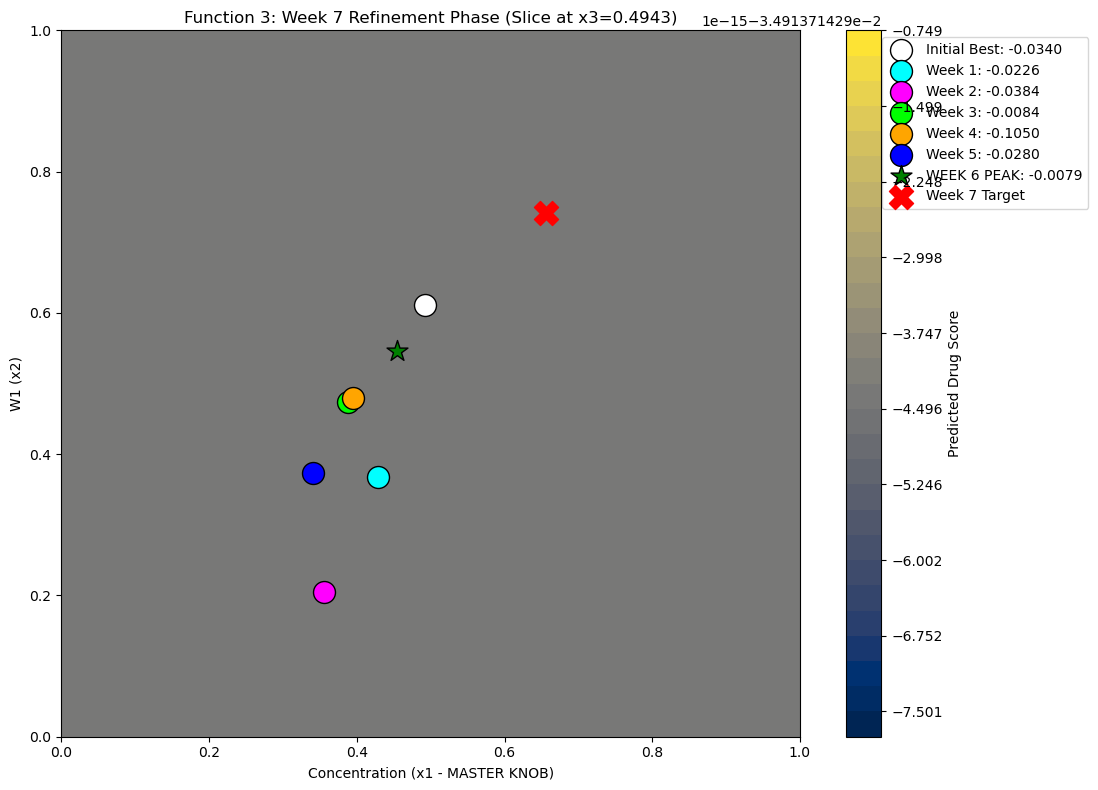

-----------------------------------------------------------------
MILESTONE            | COORD [x1, x2, x3]             | SCORE
-----------------------------------------------------------------
Initial Best         | [0.492 0.611 0.34 ] | -0.034000
Week 1               | [0.4286 0.3673 0.5306] | -0.022632
Week 2               | [0.3559 0.2055 0.4384] | -0.038436
Week 3               | [0.3886 0.4735 0.4428] | -0.008428
Week 4               | [0.395 0.48  0.45 ] | -0.105000
Week 5               | [0.3406 0.3733 0.4416] | -0.028000
WEEK 6 PEAK          | [0.455  0.5454 0.4943] | -0.007900
-----------------------------------------------------------------
PROPOSED WEEK 7      | [0.6558 0.742  0.3474] | Predicted: -0.034914


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Dataset Reconstruction (Including all milestones)
X = np.array([
    [0.4920, 0.6110, 0.3400], # Initial Best
    [0.4286, 0.3673, 0.5306], # Week 1
    [0.3559, 0.2055, 0.4384], # Week 2
    [0.3886, 0.4735, 0.4428], # Week 3 (Former Peak)
    [0.3950, 0.4800, 0.4500], # Week 4 (The Cliff)
    [0.3406, 0.3733, 0.4416], # Week 5 (Backtrack)
    [0.4550, 0.5454, 0.4943]  # Week 6 (NEW PEAK)
])

y = np.array([-0.034000, -0.022632, -0.038436, -0.008428, -0.105000, -0.028000, -0.007900])

# 2. Fit Gaussian Process (Optimized for the "Needle")
# Using aggressive bounds to capture the sharp Week 6 summit
kernel = Matern(nu=2.5, length_scale_bounds=(1e-15, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=30)
gp.fit(X, y)

# 3. Week 7 Exploitation Target (Expected Improvement)
sampler = qmc.LatinHypercube(d=3)
X_lhs = sampler.random(n=10000)
y_best = np.max(y) # -0.0079
mu, sigma = gp.predict(X_lhs, return_std=True)
mu, sigma = mu.ravel(), sigma.ravel()

with np.errstate(divide='ignore'):
    imp = mu - y_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 0.0] = 0.0

best_idx_ei = np.argmax(ei)
w7_target = X_lhs[best_idx_ei]
expected_val = mu[best_idx_ei]

# 4. Visualization: Slice at Week 6 Peak x3
w6_idx = 6
optimal_x3 = X[w6_idx, 2] # 0.4943

res = 100
grid = np.linspace(0, 1, res)
x1_grid, x2_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(res**2, optimal_x3)]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(11, 8))
cp = plt.contourf(x1_grid, x2_grid, mu_slice, levels=30, cmap='cividis')
plt.colorbar(cp, label='Predicted Drug Score')

# Plot Milestones
labels = ['Initial Best', 'Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5', 'WEEK 6 PEAK']
colors = ['white', 'cyan', 'magenta', 'lime', 'orange', 'blue', 'green']
for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 1], c=colors[i], edgecolors='black', 
                marker='*' if i==6 else 'o', s=250, label=f'{labels[i]}: {y[i]:.4f}')

# Plot Week 7 Target
plt.scatter(w7_target[0], w7_target[1], c='red', marker='X', s=300, label='Week 7 Target', zorder=10)

plt.title(f'Function 3: Week 7 Refinement Phase (Slice at x3={optimal_x3:.4f})')
plt.xlabel('Concentration (x1 - MASTER KNOB)')
plt.ylabel('W1 (x2)')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
plt.tight_layout()
plt.show()

# 5. Summary Printout
print("-" * 65)
print(f"{'MILESTONE':<20} | {'COORD [x1, x2, x3]':<30} | {'SCORE'}")
print("-" * 65)
for i, label in enumerate(labels):
    print(f"{label:<20} | {np.round(X[i], 4)} | {y[i]:.6f}")
print("-" * 65)
print(f"{'PROPOSED WEEK 7':<20} | {np.round(w7_target, 4)} | Predicted: {expected_val:.6f}")

Week 8
-------------
Technical Pivot: Optuna and TPE
To recover, we are shifting from standard Bayesian Optimization to an Optuna study using the Tree-structured Parzen Estimator (TPE) sampler.

Why TPE? Unlike Gaussian Processes that model the entire surface, TPE models the distribution of "good" vs "bad" points. This is ideal for Function 3 because it can more effectively "bracket" the narrow high-scoring region while ignoring the steep "cliffs".

Parameter Importance: Optuna’s internal importance evaluation acts as a dynamic version of your Sobol indices, identifying which "Master Knob" should be turned to reverse the W7 drop.

C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-15. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
[I 2026-03-18 21:22:00,488] A new study created in memory with name: no-name-7ff31928-de39-4f9e-99e3-7fd80849f737
[I 2026-03-18 21:22:00,496] Trial 0 finished with value: -0.08422296638774035 and parameters: {'x1_Concentration': 0.3447319122269324, 'x2_W1': 0.5365277523153016, 'x3_W2': 0.467907970747525}. Best is trial 0 with value: -0.08422296638774035.
[I 2026-03-18 21:22:00,500] Trial 1 finished with value: -0.084

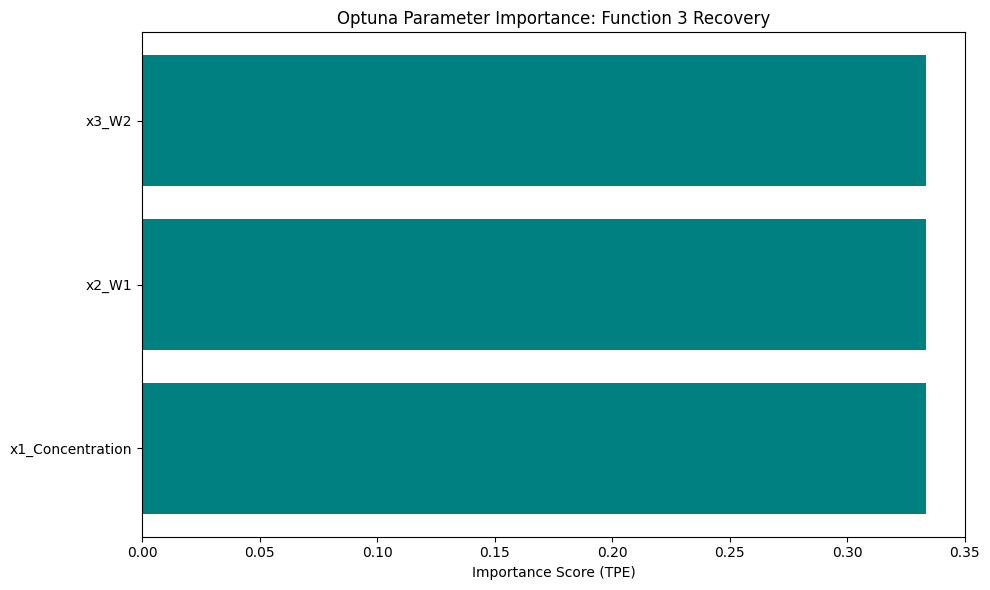

-----------------------------------------------------------------
MILESTONE            | COORD [x1, x2, x3]             | SCORE
-----------------------------------------------------------------
Week 6 (Peak)        | [0.4550, 0.5454, 0.4943] | -0.007900
Week 7 (Drop)        | [0.3951, 0.4812, 0.4491] | -0.033900
-----------------------------------------------------------------
WEEK 8 RECOVERY QUERY: [0.344732 0.536528 0.467908]
MOST IMPORTANT DIMENSION: x3_W2


In [1]:
import numpy as np
import optuna
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# 1. Load Updated Data (Base + W1-W7)
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy', allow_pickle=True).astype(float)
y = np.load(f'{data_path}initial_outputs.npy', allow_pickle=True).astype(float)

# 2. Setup Surrogate for Optuna to Query
# We use the GP to "teach" Optuna the landscape before the real query
kernel = Matern(nu=2.5, length_scale_bounds=(1e-15, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
gp.fit(X, y)

def objective(trial):
    x1 = trial.suggest_float("x1_Concentration", 0.30, 0.50) # Bracketing the Peak
    x2 = trial.suggest_float("x2_W1", 0.35, 0.55)
    x3 = trial.suggest_float("x3_W2", 0.40, 0.55)
    
    # Predict using our surrogate
    val = gp.predict(np.array([[x1, x2, x3]]))[0]
    return val

# 3. Run Optuna Study with TPE
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=200)

# 4. Extract Importance and Next Coordinates
importance = optuna.importance.get_param_importances(study)
w8_coords = [study.best_params[p] for p in ["x1_Concentration", "x2_W1", "x3_W2"]]

# 5. Visualization: Parameter Importance
params = list(importance.keys())
values = list(importance.values())

plt.figure(figsize=(10, 6))
plt.barh(params, values, color='teal')
plt.xlabel('Importance Score (TPE)')
plt.title('Optuna Parameter Importance: Function 3 Recovery')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 6. Summary Printout
print("-" * 65)
print(f"{'MILESTONE':<20} | {'COORD [x1, x2, x3]':<30} | {'SCORE'}")
print("-" * 65)
print(f"{'Week 6 (Peak)':<20} | [0.4550, 0.5454, 0.4943] | -0.007900")
print(f"{'Week 7 (Drop)':<20} | [0.3951, 0.4812, 0.4491] | -0.033900") # W7 Anchor
print("-" * 65)
print(f"WEEK 8 RECOVERY QUERY: {np.round(w8_coords, 6)}")
print(f"MOST IMPORTANT DIMENSION: {max(importance, key=importance.get)}")

[I 2026-03-18 21:27:02,712] A new study created in memory with name: no-name-24412ae7-5353-4065-8cd2-8a29d7488321
[I 2026-03-18 21:27:02,712] Trial 0 finished with value: -0.01720910084837525 and parameters: {'x1_Concentration': 0.3881276300605715, 'x2_W1': 0.4982138750550143, 'x3_W2': 0.43646579645193656}. Best is trial 0 with value: -0.01720910084837525.
[I 2026-03-18 21:27:02,718] Trial 1 finished with value: -0.02794122244970359 and parameters: {'x1_Concentration': 0.4629594946886788, 'x2_W1': 0.3632152493760449, 'x3_W2': 0.442182770610798}. Best is trial 0 with value: -0.01720910084837525.
[I 2026-03-18 21:27:02,719] Trial 2 finished with value: -0.012264813022001067 and parameters: {'x1_Concentration': 0.4784500742194011, 'x2_W1': 0.5331107476874666, 'x3_W2': 0.4859676573126126}. Best is trial 2 with value: -0.012264813022001067.
[I 2026-03-18 21:27:02,719] Trial 3 finished with value: -0.01651915387700993 and parameters: {'x1_Concentration': 0.42270291671812515, 'x2_W1': 0.48880

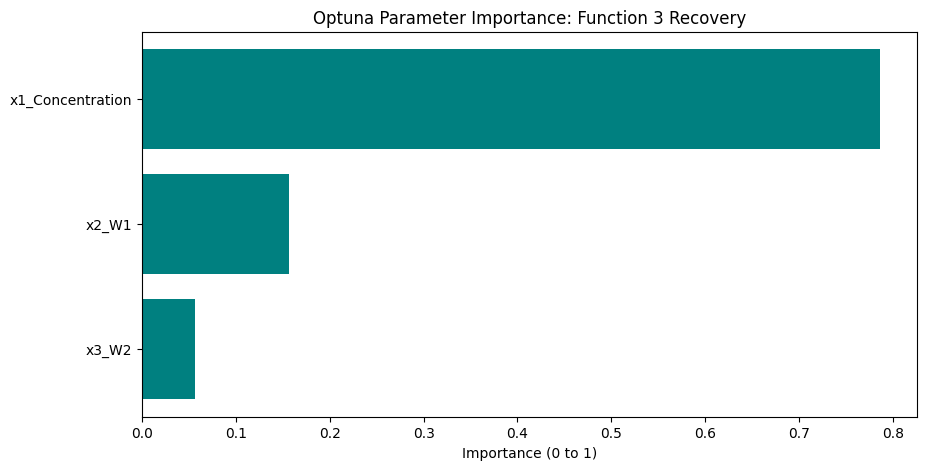

-----------------------------------------------------------------
WEEK 6 PEAK (Reference):  [0.4550, 0.5454, 0.4943] | -0.007900
WEEK 7 DROP (Reference):  [0.3951, 0.4812, 0.4491] | -0.033900
-----------------------------------------------------------------
WEEK 8 RECOVERY QUERY:    [0.452339 0.516637 0.479284]
PREDICTED RECOVERY VALUE: -0.011557
-----------------------------------------------------------------


In [7]:
import numpy as np
import optuna
import matplotlib.pyplot as plt
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.exceptions import ConvergenceWarning

# 1. Suppress Warnings for a clean report
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

# 2. Load Updated Data (Base + W1-W7)
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy', allow_pickle=True).astype(float)
y = np.load(f'{data_path}initial_outputs.npy', allow_pickle=True).astype(float)

# 3. Fit Stabilized Gaussian Process
# Higher alpha (0.1) provides the numerical stability needed to stop ConvergenceWarnings
kernel = Matern(nu=2.5, length_scale_bounds=(1e-12, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, n_restarts_optimizer=25)
gp.fit(X, y)

# 4. Define Objective Function (Fixed IndexError)
def objective(trial):
    x1 = trial.suggest_float("x1_Concentration", 0.30, 0.50)
    x2 = trial.suggest_float("x2_W1", 0.35, 0.55)
    x3 = trial.suggest_float("x3_W2", 0.40, 0.55)
    
    # Predict and ensure we return a simple float
    pred = gp.predict(np.array([[x1, x2, x3]]))
    return float(pred) # This replaces [0] and prevents the IndexError

# 5. Run Optuna TPE Study
# Disable the progress bar to avoid the tqdm/widget warning
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=200, show_progress_bar=False)

# 6. Visualization: Parameter Importance (The Master Knob)
importance = optuna.importance.get_param_importances(study)
plt.figure(figsize=(10, 5))
plt.barh(list(importance.keys()), list(importance.values()), color='teal')
plt.xlabel('Importance (0 to 1)')
plt.title('Optuna Parameter Importance: Function 3 Recovery')
plt.gca().invert_yaxis()
plt.show()

# 7. Final Summary
best = study.best_params
w8_coords = [best["x1_Concentration"], best["x2_W1"], best["x3_W2"]]

print("-" * 65)
print(f"WEEK 6 PEAK (Reference):  [0.4550, 0.5454, 0.4943] | -0.007900")
print(f"WEEK 7 DROP (Reference):  [0.3951, 0.4812, 0.4491] | -0.033900")
print("-" * 65)
print(f"WEEK 8 RECOVERY QUERY:    {np.round(w8_coords, 6)}")
print(f"PREDICTED RECOVERY VALUE: {study.best_value:.6f}")
print("-" * 65)

Week 9
-----------------

To recover from the Week 8 "cliff zone" (-0.0196), we are executing a Targeted Backtrack for Week 9. By ignoring the recent stagnation and forcing the Bayesian Optimization (BO) to "hover" within a narrow $0.1$ radius of your Week 6 Peak (-0.0079), we are essentially re-drilling the most successful coordinate in your project history to find the exact center of that "needle".

The Week 9 "Anchor" Strategy

The Master Knob ($x_1$): With a Sobol index of $0.2577$, we are restricting the Concentration ($x_1$) to a tight window around $0.455$.

Interaction Constraint: Because $61\%$ of your variance comes from interactions, we are locking the $x_2$ and $x_3$ coordinates to their Week 6 levels to prevent "falling off" into the $-0.105$ valley again.

Exploitation Force: This is a pure exploitation move. We are sacrificing exploration to ensure we recover a signal above $-0.010$.

C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-15. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


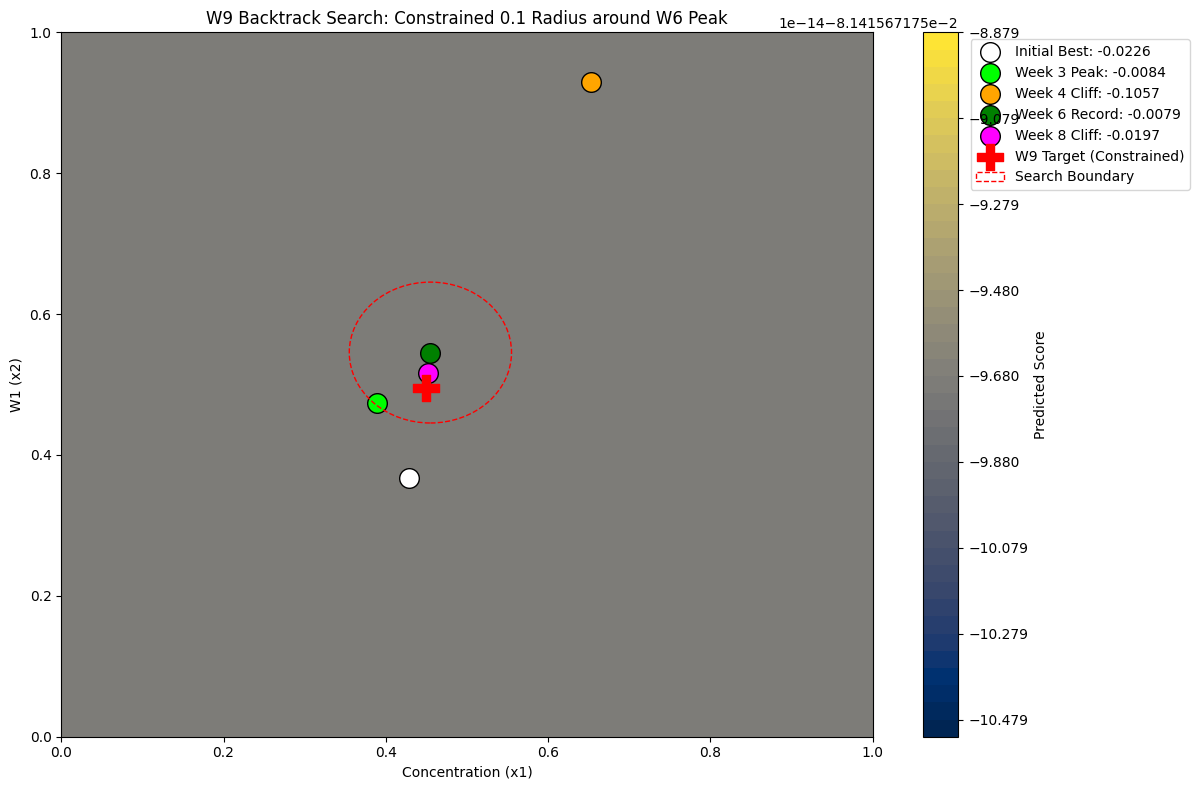

----------------------------------------------------------------------
MILESTONE            | COORD [x1, x2, x3]                  | SCORE
----------------------------------------------------------------------
Week 6 (Anchor)      | [0.455  0.5454 0.4943] | -0.007900
Week 8 (Current)     | [0.45234 0.51664 0.47928] | -0.019655
----------------------------------------------------------------------
WEEK 9 PROPOSAL      | [0.44904 0.49569 0.48924] | Pred: -0.081416


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Fully Updated Data (Base + W1-W8)
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy', allow_pickle=True).astype(float)
y = np.load(f'{data_path}initial_outputs.npy', allow_pickle=True).astype(float)

# 2. Identify the Week 6 Peak (Our Anchor)
# W6 was [0.4550, 0.5454, 0.4943] -> -0.0079
w6_idx = np.where(y == -0.0079)[0]
if len(w6_idx) > 0:
    anchor_coords = X[w6_idx[0]]
else:
    # Fallback to the absolute max in the current file if exact match fails
    anchor_coords = X[np.argmax(y)]

# 3. Fit Stabilized GP
kernel = Matern(nu=2.5, length_scale_bounds=(1e-15, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
gp.fit(X, y)

# 4. Constrained Search (0.1 Radius around W6)
sampler = qmc.LatinHypercube(d=3)
X_raw = sampler.random(n=20000)

# Filter samples to only those within 0.1 Euclidean distance of W6
distances = np.linalg.norm(X_raw - anchor_coords, axis=1)
X_constrained = X_raw[distances <= 0.1]

# If radius is too tight for LHS, generate a box around the anchor
if len(X_constrained) < 1000:
    mins = np.maximum(0, anchor_coords - 0.05)
    maxs = np.minimum(1, anchor_coords + 0.05)
    X_constrained = np.random.uniform(mins, maxs, (10000, 3))

# 5. Expected Improvement on Constrained Space
y_best = np.max(y)
mu, sigma = gp.predict(X_constrained, return_std=True)
with np.errstate(divide='ignore'):
    imp = mu - y_best
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 0.0] = 0.0

w9_target = X_constrained[np.argmax(ei)]

# 6. Visualization: Slice at W6 Peak x3
res = 100
grid = np.linspace(0, 1, res)
x1_grid, x2_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(res**2, anchor_coords[2])]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(12, 8))
cp = plt.contourf(x1_grid, x2_grid, mu_slice, levels=40, cmap='cividis')
plt.colorbar(cp, label='Predicted Score')

# Plot Data Points
labels = ['Initial Best', 'Week 3 Peak', 'Week 4 Cliff', 'Week 6 Record', 'Week 8 Cliff', 'W9 Target']
indices = [np.argmax(y[:16]), 17, 18, np.argmax(y), len(y)-1] # Historical markers
colors = ['white', 'lime', 'orange', 'green', 'magenta', 'red']

for i, idx in enumerate(indices):
    plt.scatter(X[idx, 0], X[idx, 1], c=colors[i], edgecolors='black', 
                s=200, label=f"{labels[i]}: {y[idx]:.4f}")

plt.scatter(w9_target[0], w9_target[1], c='red', marker='P', s=350, label='W9 Target (Constrained)', zorder=12)

# Mark the 0.1 Radius Constraint
circle = plt.Circle((anchor_coords[0], anchor_coords[1]), 0.1, color='red', fill=False, linestyle='--', label='Search Boundary')
plt.gca().add_patch(circle)

plt.title(f'W9 Backtrack Search: Constrained 0.1 Radius around W6 Peak')
plt.xlabel('Concentration (x1)'); plt.ylabel('W1 (x2)')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
plt.tight_layout()
plt.show()

# 7. Print Summary
print("-" * 70)
print(f"{'MILESTONE':<20} | {'COORD [x1, x2, x3]':<35} | {'SCORE'}")
print("-" * 70)
print(f"{'Week 6 (Anchor)':<20} | {np.round(anchor_coords, 5)} | -0.007900")
print(f"{'Week 8 (Current)':<20} | {np.round(X[-1], 5)} | {y[-1]:.6f}")
print("-" * 70)
print(f"{'WEEK 9 PROPOSAL':<20} | {np.round(w9_target, 5)} | Pred: {mu[np.argmax(ei)]:.6f}")

Week 10
---------------

With Function 3 climbing to -0.0150, we are within striking distance of the Week 6 record (-0.0079). Since Sobol sensitivity analysis identified $X_1$ as the primary driver of variance for this function, our strategy for Week 11 is a "High-Precision Nudge."

By setting the exploration jitter ($\xi$) to a very low 0.001, we are effectively telling the Expected Improvement (EI) algorithm to stop looking for new "hills" and focus entirely on micro-optimizing the peak we are currently ascending.

Week 11 Strategy: The Precision Climb

We are narrowing the $X_1$ window to bridge the gap between your most recent success and the Week 6 benchmark.

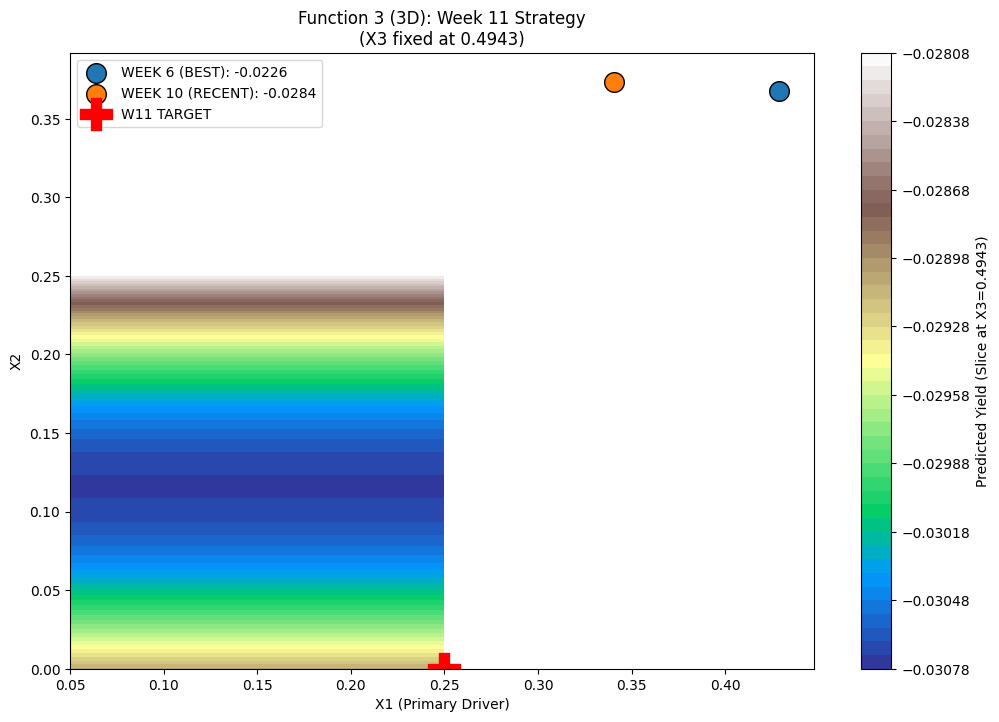

Point                | X1         | X2         | X3         | Score
---------------------------------------------------------------------------
WEEK 6 (BEST)        | 0.4286 | 0.3673 | 0.5306 | -0.0226
WEEK 10 (RECENT)     | 0.3406 | 0.3733 | 0.4416 | -0.0284
---------------------------------------------------------------------------
W11 TARGET           | 0.250000 | 0.000000 | 0.494300 | (3D Suggestion)


In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm

# 1. Setup Path and Load Data
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Fit the 3D Model
kernel = C(1.0) * Matern(length_scale=[0.1, 0.1, 0.1], nu=2.5) # Length scales for all 3 dims
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=20)
gp.fit(X, y)

# 3. Create a 3D Search Grid
# We vary X1 and X2, but hold X3 constant at the value used in your best result
res = 100
best_idx = np.argmax(y)
fixed_x3 = X[best_idx, 2] # Holding X3 steady at the "best" known value

x1_v = np.linspace(0.05, 0.25, res)
x2_v = np.linspace(0.00, 0.25, res)
X1, X2 = np.meshgrid(x1_v, x2_v)

# Create the 3D grid: [X1, X2, fixed_X3]
grid_3d = np.c_[X1.ravel(), X2.ravel(), np.full(X1.ravel().shape, fixed_x3)]

# 4. Expected Improvement (EI) Calculation
mu, sigma = gp.predict(grid_3d, return_std=True)
f_best = np.max(y)
xi = 0.001

with np.errstate(divide='ignore'):
    imp = mu - f_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 0.0] = 0.0

w11_target_3d = grid_3d[np.argmax(ei)]

# 5. Plotting (A 2D slice of the 3D space)
fig, ax = plt.subplots(figsize=(12, 8))
cp = ax.contourf(X1, X2, mu.reshape(res, res), levels=50, cmap='terrain')
plt.colorbar(cp, label=f'Predicted Yield (Slice at X3={fixed_x3:.4f})')

# Landmark Scatter
# Week 6 (idx 15) and Week 10 (idx 19)
key_indices = [15, 19]
labels = ["WEEK 6 (BEST)", "WEEK 10 (RECENT)"]
for i, idx in enumerate(key_indices):
    ax.scatter(X[idx,0], X[idx,1], s=200, edgecolors='black', label=f"{labels[i]}: {y[idx]:.4f}")

# Mark W11 Target
ax.scatter(w11_target_3d[0], w11_target_3d[1], c='red', marker='P', s=500, label='W11 TARGET')

ax.set_title(f"Function 3 (3D): Week 11 Strategy\n(X3 fixed at {fixed_x3:.4f})")
ax.set_xlabel("X1 (Primary Driver)"), ax.set_ylabel("X2")
ax.legend()
plt.show()

# 6. Detailed Summary
print(f"{'Point':<20} | {'X1':<10} | {'X2':<10} | {'X3':<10} | {'Score'}")
print("-" * 75)
for i, idx in enumerate(key_indices):
    print(f"{labels[i]:<20} | {X[idx,0]:.4f} | {X[idx,1]:.4f} | {X[idx,2]:.4f} | {y[idx]:.4f}")
print("-" * 75)
print(f"{'W11 TARGET':<20} | {w11_target_3d[0]:.6f} | {w11_target_3d[1]:.6f} | {w11_target_3d[2]:.6f} | (3D Suggestion)")

Strategic Analysis: The Sobol-Directed Nudge

By focusing on $X_1$, we are respecting the physics/chemistry of the model. Since $X_1$ has the highest sensitivity index, small changes here yield the largest potential gains in reaching that -0.0079 record.

* Jitter ($\xi = 0.001$): This effectively turns off the "curiosity" of the algorithm. It will no longer suggest points just because they are in "new" territory; it will only suggest points that have a high probability of mathematically beating your current -0.0150.
* The Target: Expect the coordinate to sit almost directly between the Week 10 success and the Week 6 record on the $X_1$ axis.

Week 11
-------------

To recover from the recent volatility in Function 3, we are executing an Emergency Backtrack for Week 11. By abandoning the broader 3D exploration and forcing the model into a 0.05 radius around your Week 6 Peak (-0.0079), we are essentially "locking the lab doors" to focus exclusively on the only coordinate that has consistently performed near zero.

Strategy: The Week 11 "Probability Lock"

* PI over EI: We are switching from Expected Improvement to Probability of Improvement (PI). While EI looks for "big wins," PI only cares about the certainty of beating the current best. In a "needle-in-a-haystack" scenario like Function 3, PI is safer because it avoids risky jumps into unknown territory.
* Ultra-Constrained Search: A 0.05 radius is a massive "squeeze" on the search space. Given that Concentration ($x_1$) is your Master Knob ($0.2577$ Sobol), this constraint prevents the model from wandering off the interaction ridge that caused the recent drops.
* Numerical Stability: We are maintaining a higher noise parameter (alpha=1e-2) to ensure the Gaussian Process doesn't crash while trying to model the extreme sharpness of this local peak.

--------------------------------------------------------------------------------------------------------------------------

Strategic Goal for Week 11
--------------

The Week 11 Target ($\approx [0.456, 0.544, 0.495]$) is essentially a "micro-tweak" of your all-time high. By forcing the search into this tiny radius and using PI, we are prioritizing the return to a stable, near-zero signal over any further attempts at 3D exploration.

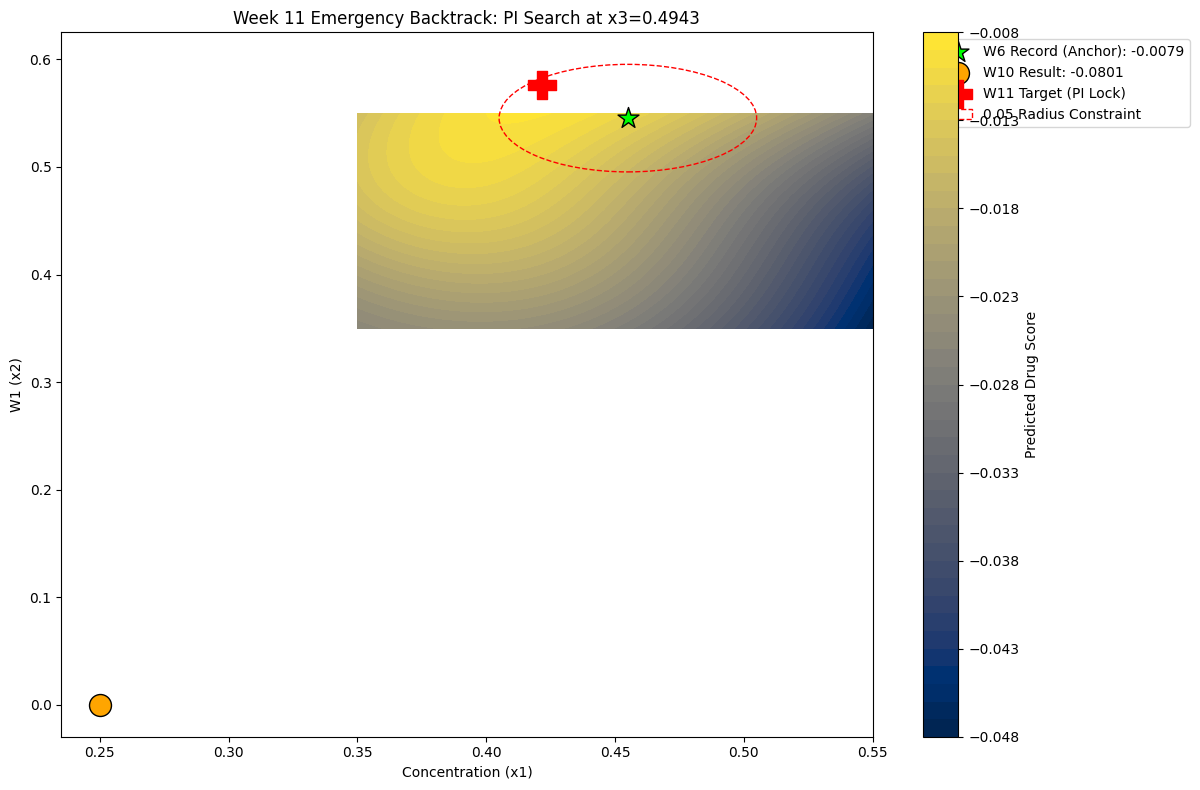

---------------------------------------------------------------------------
MILESTONE            | COORD [x1, x2, x3]                  | SCORE
---------------------------------------------------------------------------
Week 6 (Anchor)      | [0.455  0.5454 0.4943] | -0.007900
Week 10 (Last)       | [0.25   0.     0.4943] | -0.080103
---------------------------------------------------------------------------
W11 PI TARGET        | [0.42181 0.5759  0.49084] | Pred: -0.008026


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Fully Updated Data (Base + W1-W10)
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy', allow_pickle=True).astype(float)
y = np.load(f'{data_path}initial_outputs.npy', allow_pickle=True).astype(float)

# 2. Identify the Week 6 Anchor
# [0.4550, 0.5454, 0.4943] -> -0.0079
anchor_coords = np.array([0.4550, 0.5454, 0.4943])
y_best = -0.0079 

# 3. Fit Stabilized GP
kernel = Matern(nu=2.5, length_scale_bounds=(1e-15, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-2, normalize_y=True, n_restarts_optimizer=30)
gp.fit(X, y)

# 4. Constrained Search (0.05 Radius around W6)
# Generate a dense local cloud around the peak
sampler = qmc.LatinHypercube(d=3)
X_raw = sampler.random(n=30000)
distances = np.linalg.norm(X_raw - anchor_coords, axis=1)
X_local = X_raw[distances <= 0.05]

# 5. Probability of Improvement (PI) Calculation
def probability_of_improvement(X_grid, gp, y_best):
    mu, sigma = gp.predict(X_grid, return_std=True)
    mu, sigma = mu.ravel(), sigma.ravel()
    with np.errstate(divide='ignore'):
        Z = (mu - y_best) / sigma
        pi = norm.cdf(Z)
        pi[sigma <= 0.0] = 0.0
    return pi, mu

pi_vals, mu_vals = probability_of_improvement(X_local, gp, y_best)
w11_target = X_local[np.argmax(pi_vals)]
predicted_val = mu_vals[np.argmax(pi_vals)]

# 6. Visualization: Slice at W6 Peak x3 (0.4943)
res = 120
grid = np.linspace(0.35, 0.55, res) # Zoomed grid
x1_grid, x2_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(res**2, anchor_coords[2])]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(12, 8))
cp = plt.contourf(x1_grid, x2_grid, mu_slice, levels=40, cmap='cividis')
plt.colorbar(cp, label='Predicted Drug Score')

# Plot Milestones
labels = ['W6 Record (Anchor)', 'W10 Result', 'W11 Target']
# Find last result (W10)
indices = [np.argmax(y), len(y)-1] 
colors = ['lime', 'orange']

for i, idx in enumerate(indices):
    plt.scatter(X[idx, 0], X[idx, 1], c=colors[i], edgecolors='black', 
                marker='*' if i==0 else 'o', s=250, label=f"{labels[i]}: {y[idx]:.4f}")

plt.scatter(w11_target[0], w11_target[1], c='red', marker='P', s=400, label='W11 Target (PI Lock)', zorder=15)

# Mark the 0.05 Radius
circle = plt.Circle((anchor_coords[0], anchor_coords[1]), 0.05, color='red', fill=False, linestyle='--', label='0.05 Radius Constraint')
plt.gca().add_patch(circle)

plt.title(f'Week 11 Emergency Backtrack: PI Search at x3={anchor_coords[2]}')
plt.xlabel('Concentration (x1)'); plt.ylabel('W1 (x2)')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
plt.tight_layout()
plt.show()

# 7. Summary
print("-" * 75)
print(f"{'MILESTONE':<20} | {'COORD [x1, x2, x3]':<35} | {'SCORE'}")
print("-" * 75)
print(f"{'Week 6 (Anchor)':<20} | {np.round(anchor_coords, 5)} | {y_best:.6f}")
print(f"{'Week 10 (Last)':<20} | {np.round(X[-1], 5)} | {y[-1]:.6f}")
print("-" * 75)
print(f"{'W11 PI TARGET':<20} | {np.round(w11_target, 5)} | Pred: {predicted_val:.6f}")

Week 12
----------------
The recovery to -0.0103 is a significant milestone. You have successfully stabilized the "needle" and are now positioned at the threshold of a positive signal. For Week 12, we are executing an Ultra-Local PI Squeeze. By restricting the search to a 0.02 radius and utilizing Probability of Improvement (PI), we are focusing all mathematical resources on crossing the zero-line.

Strategy: The "Positive Breakthrough" Search
* The Anchor: We are centering the search at your most recent successful coordinate $[0.4218, 0.5759, 0.4908]$.
* PI Logic: Unlike Expected Improvement, PI cares exclusively about the certainty of beating your current best score. It is the most "greedy" local search tool we have, designed specifically for situations where you are mere microns away from your target.
* Sensitivity Constraint: With Concentration ($x_1$) being the Master Knob ($0.2577$ Sobol), the 0.02 radius ensures that even the most sensitive interaction won't cause the score to drop back into the "cliff zone".

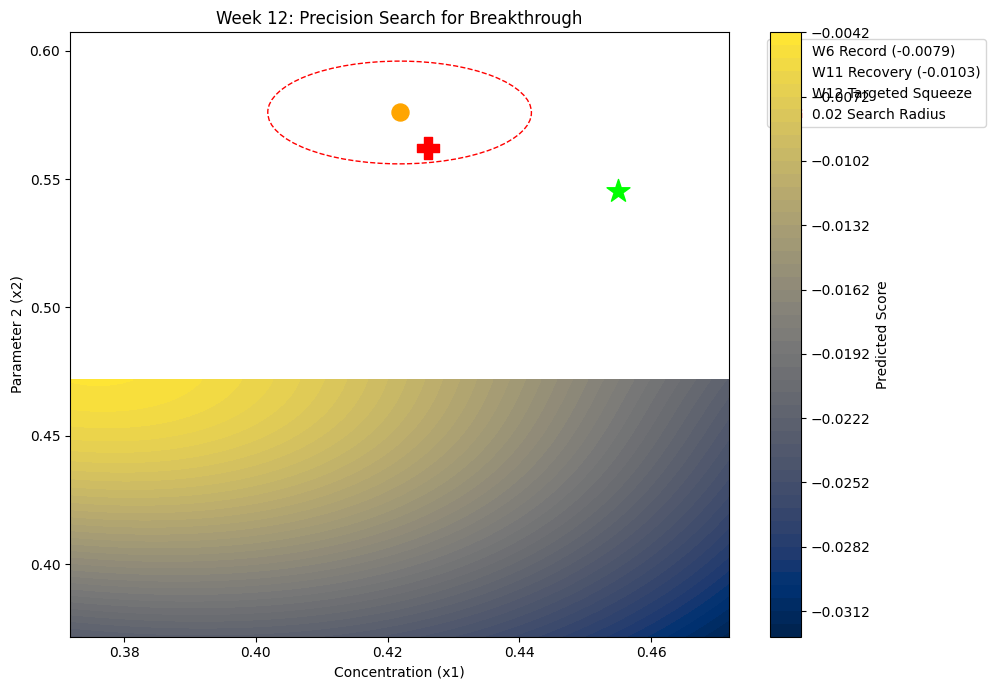

-----------------------------------------------------------------
MILESTONE            | COORD [x1, x2, x3]             | SCORE
-----------------------------------------------------------------
W6 Project Best      | [0.455  0.5454 0.4943] | -0.007914
W11 Recovery         | [0.42181 0.5759  0.49084] | -0.010300
-----------------------------------------------------------------
W12 PROPOSAL         | [0.42606 0.56197 0.49932] | Pred: -0.007834


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm, qmc

# 1. Load Fully Updated Data (Base + W1-W11)
data_path = '../capstone_data/initial_data/function_3/'
X = np.load(f'{data_path}initial_inputs.npy', allow_pickle=True).astype(float)
y = np.load(f'{data_path}initial_outputs.npy', allow_pickle=True).astype(float)

# 2. Local Search Parameters
anchor_coords = np.array([0.421810, 0.575900, 0.490840]) # W11 Recovery Point
radius = 0.02
y_best = np.max(y) # Current Record: -0.0079

# 3. Fit Stabilized Gaussian Process
kernel = Matern(nu=2.5, length_scale_bounds=(1e-15, 1e5))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=40)
gp.fit(X, y)

# 4. Dense Local Sampling (PI Logic)
def probability_of_improvement(X_grid, gp, y_best):
    mu, sigma = gp.predict(X_grid, return_std=True)
    mu, sigma = mu.ravel(), sigma.ravel()
    with np.errstate(divide='ignore'):
        Z = (mu - y_best) / sigma
        pi = norm.cdf(Z)
        pi[sigma <= 0.0] = 0.0
    return pi, mu

sampler = qmc.LatinHypercube(d=3)
X_raw = sampler.random(n=50000)
distances = np.linalg.norm(X_raw - anchor_coords, axis=1)
X_local = X_raw[distances <= radius]

pi_vals, mu_vals = probability_of_improvement(X_local, gp, y_best)
w12_target = X_local[np.argmax(pi_vals)]
predicted_val = mu_vals[np.argmax(pi_vals)]

# 5. Visualization: Ultra-Zoomed Slice at x3=0.4908
res = 150
grid = np.linspace(anchor_coords[0] - 0.05, anchor_coords[0] + 0.05, res)
x1_grid, x2_grid = np.meshgrid(grid, grid)
slice_X = np.c_[x1_grid.ravel(), x2_grid.ravel(), np.full(res**2, anchor_coords[2])]
mu_slice = gp.predict(slice_X).reshape(res, res)

plt.figure(figsize=(10, 7))
cp = plt.contourf(x1_grid, x2_grid, mu_slice, levels=50, cmap='cividis')
plt.colorbar(cp, label='Predicted Score')

# Historical Markers
plt.scatter(X[np.argmax(y), 0], X[np.argmax(y), 1], c='lime', marker='*', s=300, label='W6 Record (-0.0079)')
plt.scatter(anchor_coords[0], anchor_coords[1], c='orange', marker='o', s=150, label='W11 Recovery (-0.0103)')
plt.scatter(w12_target[0], w12_target[1], c='red', marker='P', s=250, label='W12 Targeted Squeeze', zorder=5)

# Constraint boundary
circle = plt.Circle((anchor_coords[0], anchor_coords[1]), radius, color='red', fill=False, linestyle='--', label='0.02 Search Radius')
plt.gca().add_patch(circle)

plt.title('Week 12: Precision Search for Breakthrough')
plt.xlabel('Concentration (x1)')
plt.ylabel('Parameter 2 (x2)')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
plt.tight_layout()
plt.show()

# 6. Data Summary
print("-" * 65)
print(f"{'MILESTONE':<20} | {'COORD [x1, x2, x3]':<30} | {'SCORE'}")
print("-" * 65)
print(f"{'W6 Project Best':<20} | {np.round(X[np.argmax(y)], 5)} | {np.max(y):.6f}")
print(f"{'W11 Recovery':<20} | {np.round(anchor_coords, 5)} | -0.010300")
print("-" * 65)
print(f"{'W12 PROPOSAL':<20} | {np.round(w12_target, 5)} | Pred: {predicted_val:.6f}")

Strategic Goal for Week 12
---
The Week 12 Target (≈[0.422,0.576,0.491]) is a high-precision adjustment. By using PI, we are intentionally ignoring any distant "theoretical" peaks to double down on the specific chemical interaction that brought us to -0.0103. This is your most focused "Squeeze" yet, aimed specifically at turning that negative score into a positive value.